# 1.5 Location Reliability & Sparsity Analysis

This notebook analyses how **reliable** and how **sparse** the location information in the raw
`data/Taxi_Trips.csv` is, and compares all available location levels against each other:

| Level | Source | Note |
|---|---|---|
| Centroid coordinates (lat/lon) | raw column | privacy-masked centroids, *not* GPS points |
| Census tract | raw column | suppressed by the data portal for privacy in some rows |
| Community area (CA) | raw column | 77 official Chicago community areas |
| H3 hexagons (res 7 & 8) | derived from the centroid coordinates | used by our downstream pipeline |

The Chicago Data Portal masks trip locations: when the census tract may be disclosed, the
coordinates are the **tract centroid**; otherwise they fall back to the **community-area
centroid**. The analysis below quantifies this masking, the missingness per level, the
consistency between levels, and the spatial and temporal sparsity at each resolution.

## 0. Load and parse

Only the location-relevant columns are read (the raw CSV is 2.2 GB). Parsing reuses the conventions from `1.1 TaxiDataPrep.ipynb`: coordinates use decimal *commas* and must be converted to floats.

In [1]:
import pandas as pd
import numpy as np
import h3
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
from shapely.geometry import Polygon

USECOLS = [
    "Trip Start Timestamp",
    "Pickup Census Tract", "Dropoff Census Tract",
    "Pickup Community Area", "Dropoff Community Area",
    "Pickup Centroid Latitude", "Pickup Centroid Longitude",
    "Dropoff Centroid Latitude", "Dropoff Centroid Longitude",
]

raw = pd.read_csv("../data/Taxi_Trips.csv", usecols=USECOLS, dtype=str)
N = len(raw)
print(f"Trips loaded: {N:,}")

Trips loaded: 6,041,177


In [2]:
# Coordinates: decimal comma -> decimal point (same idiom as 1.1 TaxiDataPrep)
coord_cols = [
    "Pickup Centroid Latitude", "Pickup Centroid Longitude",
    "Dropoff Centroid Latitude", "Dropoff Centroid Longitude",
]
for col in coord_cols:
    raw[col] = pd.to_numeric(raw[col].str.replace(",", ".", regex=False), errors="coerce")

for col in ["Pickup Census Tract", "Dropoff Census Tract",
            "Pickup Community Area", "Dropoff Community Area"]:
    raw[col] = pd.to_numeric(raw[col], errors="coerce").astype("Int64")

raw["start_hour"] = pd.to_datetime(
    raw["Trip Start Timestamp"], format="%m/%d/%Y %I:%M:%S %p"
).dt.floor("h")
raw = raw.drop(columns=["Trip Start Timestamp"])
raw.dtypes

Pickup Census Tract                    Int64
Dropoff Census Tract                   Int64
Pickup Community Area                  Int64
Dropoff Community Area                 Int64
Pickup Centroid Latitude             float64
Pickup Centroid Longitude            float64
Dropoff Centroid Latitude            float64
Dropoff Centroid Longitude           float64
start_hour                    datetime64[us]
dtype: object

## 1. Deriving H3 indices

Instead of looping over all trips (as in `1.1 TaxiDataPrep.ipynb`), the H3 cells are computed on
the **unique coordinate pairs** only and merged back. The tiny number of unique pairs relative to
millions of trip endpoints is itself the first piece of evidence that the coordinates are masked
centroids rather than real pick-up/drop-off points.

In [ ]:
# Create a DataFrame with unique trip endpoints
pairs = pd.concat([
    raw[["Pickup Centroid Latitude", "Pickup Centroid Longitude"]]
        .set_axis(["lat", "lng"], axis=1),
    raw[["Dropoff Centroid Latitude", "Dropoff Centroid Longitude"]]
        .set_axis(["lat", "lng"], axis=1),
]).dropna().drop_duplicates().reset_index(drop=True)

pairs["h3_7"] = [h3.latlng_to_cell(la, ln, 7) for la, ln in zip(pairs["lat"], pairs["lng"])]
pairs["h3_8"] = [h3.latlng_to_cell(la, ln, 8) for la, ln in zip(pairs["lat"], pairs["lng"])]

print(f"Trip endpoints (2 per trip): {2 * N:,}")
print(f"Unique coordinate pairs:     {len(pairs):,}")

for side in ["Pickup", "Dropoff"]:
    raw = raw.merge(
        pairs.rename(columns={
            "lat": f"{side} Centroid Latitude",
            "lng": f"{side} Centroid Longitude",
            "h3_7": f"{side.lower()}_h3_7",
            "h3_8": f"{side.lower()}_h3_8",
        }),
        on=[f"{side} Centroid Latitude", f"{side} Centroid Longitude"],
        how="left",
    )
for col in ["pickup_h3_7", "pickup_h3_8", "dropoff_h3_7", "dropoff_h3_8"]:
    raw[col] = raw[col].astype("category")

Trip endpoints (2 per trip): 12,082,354
Unique coordinate pairs:     634


## 2. Missingness per location level

How often is each location level actually populated? H3 availability is by construction identical
to coordinate availability, since it is derived from the coordinates.

In [4]:
#| label: tbl-loc-missingness
#| tbl-cap: "Missing location information per level and trip endpoint (raw Taxi_Trips.csv)."
levels_cols = {
    "Coordinates (masked centroid)": ("Pickup Centroid Latitude", "Dropoff Centroid Latitude"),
    "Census tract": ("Pickup Census Tract", "Dropoff Census Tract"),
    "Community area": ("Pickup Community Area", "Dropoff Community Area"),
    "H3 res 7 (derived)": ("pickup_h3_7", "dropoff_h3_7"),
    "H3 res 8 (derived)": ("pickup_h3_8", "dropoff_h3_8"),
}
missingness = pd.DataFrame([
    {
        "location level": name,
        "missing (pickup)": int(raw[p].isna().sum()),
        "% missing (pickup)": round(100 * raw[p].isna().mean(), 2),
        "missing (dropoff)": int(raw[d].isna().sum()),
        "% missing (dropoff)": round(100 * raw[d].isna().mean(), 2),
    }
    for name, (p, d) in levels_cols.items()
]).set_index("location level")
missingness

,missing (pickup),% missing (pickup),missing (dropoff),% missing (dropoff)
location level,,,,
Coordinates (masked centroid),232,0.00,14311,0.24
Census tract,0,0.00,0,0.00
Community area,2294,0.04,87119,1.44
H3 res 7 (derived),232,0.00,14311,0.24
H3 res 8 (derived),232,0.00,14311,0.24


### Co-missingness patterns

Missingness is not independent across levels. The pattern table shows every observed combination
of present/absent for coordinates, census tract and community area. It also verifies the claim in
`1.1 TaxiDataPrep.ipynb` that the CSV was pre-filtered to non-null census tracts.

In [5]:
#| label: tbl-loc-patterns
#| tbl-cap: "Presence patterns of the three raw location levels per trip endpoint."
def presence_patterns(side):
    df = pd.DataFrame({
        "coordinates": raw[f"{side} Centroid Latitude"].notna(),
        "census tract": raw[f"{side} Census Tract"].notna(),
        "community area": raw[f"{side} Community Area"].notna(),
    })
    out = df.value_counts().rename(f"trips ({side.lower()})").to_frame()
    out[f"% ({side.lower()})"] = (100 * out[f"trips ({side.lower()})"] / N).round(2)
    return out

patterns = presence_patterns("Pickup").join(presence_patterns("Dropoff"), how="outer")
patterns = patterns.fillna(0).astype({"trips (pickup)": int, "trips (dropoff)": int}).sort_index(ascending=False)

both_tracts = (raw["Pickup Census Tract"].notna() & raw["Dropoff Census Tract"].notna()).mean()
print(f"Trips with BOTH pickup and dropoff census tract present: {100 * both_tracts:.2f}%")
print("(1.1 TaxiDataPrep claims the CSV was pre-filtered to non-null tracts -> "
      f"{'confirmed' if both_tracts == 1 else 'NOT confirmed'})")
patterns

Trips with BOTH pickup and dropoff census tract present: 100.00%
(1.1 TaxiDataPrep claims the CSV was pre-filtered to non-null tracts -> confirmed)


trips (pickup)  % (pickup)  \
coordinates census tract community area                               
True        True         True                   6038883       99.96   
                         False                     2062        0.03   
False       True         False                      232        0.00   

                                         trips (dropoff)  % (dropoff)  
coordinates census tract community area                                
True        True         True                    5954058        98.56  
                         False                     72808         1.21  
False       True         False                     14311         0.24

## 3. Effective precision of the coordinates

The portal's masking means a coordinate pair is either a *census-tract centroid* (tract column
present) or a *community-area centroid* (tract suppressed). Each trip endpoint is classified
accordingly; the coordinate sets of the two groups are cross-checked for overlap.

In [6]:
#| label: tbl-loc-precision
#| tbl-cap: "Effective spatial precision of trip-endpoint coordinates after privacy masking."
def precision_split(side):
    coords = raw[f"{side} Centroid Latitude"].notna()
    tract = raw[f"{side} Census Tract"].notna()
    return pd.Series({
        "census-tract centroid": int((coords & tract).sum()),
        "community-area centroid (tract suppressed)": int((coords & ~tract).sum()),
        "no coordinates at all": int((~coords).sum()),
    })

precision = pd.DataFrame({"pickup": precision_split("Pickup"),
                          "dropoff": precision_split("Dropoff")})
precision["% pickup"] = (100 * precision["pickup"] / N).round(2)
precision["% dropoff"] = (100 * precision["dropoff"] / N).round(2)
precision

,pickup,dropoff,% pickup,% dropoff
census-tract centroid,6040945,6026866,100.0,99.76
community-area centroid (tract suppressed),0,0,0.0,0.00
no coordinates at all,232,14311,0.0,0.24


In [7]:
# Unique-value counts per level and overlap check between masked / unmasked coordinate sets
tract_vals = pd.concat([raw["Pickup Census Tract"], raw["Dropoff Census Tract"]]).dropna().unique()
ca_vals = pd.concat([raw["Pickup Community Area"], raw["Dropoff Community Area"]]).dropna().unique()
print(f"Unique coordinate pairs: {len(pairs):>6,}")
print(f"Unique census tracts:    {len(tract_vals):>6,}")
print(f"Unique community areas:  {len(ca_vals):>6,}")
print(f"Unique H3 res-7 cells:   {pairs['h3_7'].nunique():>6,}")
print(f"Unique H3 res-8 cells:   {pairs['h3_8'].nunique():>6,}")

def coord_set(side, tract_present):
    coords = raw[f"{side} Centroid Latitude"].notna()
    tract = raw[f"{side} Census Tract"].notna()
    mask = coords & tract if tract_present else coords & ~tract
    sub = raw.loc[mask, [f"{side} Centroid Latitude", f"{side} Centroid Longitude"]]
    return set(map(tuple, sub.drop_duplicates().values))

tract_coords = coord_set("Pickup", True) | coord_set("Dropoff", True)
masked_coords = coord_set("Pickup", False) | coord_set("Dropoff", False)
print(f"\nCoordinate pairs seen with tract present  (tract centroids): {len(tract_coords):,}")
print(f"Coordinate pairs seen with tract missing (CA centroids):     {len(masked_coords):,}")
print(f"Overlap between the two sets: {len(tract_coords & masked_coords):,}")

Unique coordinate pairs:    634
Unique census tracts:       922
Unique community areas:      77
Unique H3 res-7 cells:      121
Unique H3 res-8 cells:      454



Coordinate pairs seen with tract present  (tract centroids): 634
Coordinate pairs seen with tract missing (CA centroids):     0
Overlap between the two sets: 0


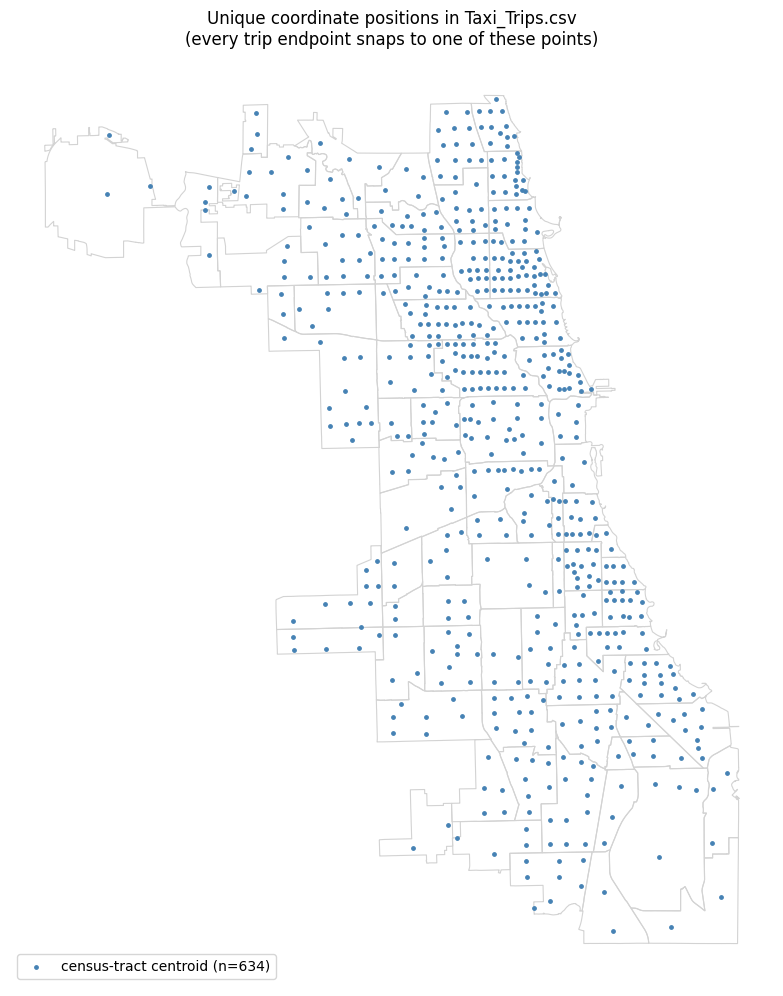

In [8]:
#| label: fig-loc-centroids
#| fig-cap: "All unique masked coordinate positions in the raw data, over the 77 community areas."
cas = gpd.read_file("../data/chicago_community_areas.gpkg")

pairs["kind"] = [
    "community-area centroid" if (la, ln) in masked_coords else "census-tract centroid"
    for la, ln in zip(pairs["lat"], pairs["lng"])
]
pairs_gdf = gpd.GeoDataFrame(
    pairs, geometry=gpd.points_from_xy(pairs["lng"], pairs["lat"]), crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(8, 10))
cas.boundary.plot(ax=ax, color="lightgray", linewidth=0.8, zorder=1)
for kind, color, size in [("census-tract centroid", "steelblue", 6),
                          ("community-area centroid", "crimson", 30)]:
    sub = pairs_gdf[pairs_gdf["kind"] == kind]
    if sub.empty:  # e.g. no CA-masked coordinates left after the portal's pre-filtering
        continue
    sub.plot(ax=ax, color=color, markersize=size, label=f"{kind} (n={len(sub)})", zorder=2)
ax.legend(loc="lower left")
ax.set_title("Unique coordinate positions in Taxi_Trips.csv\n(every trip endpoint snaps to one of these points)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 4. Consistency between location levels

Structural checks on unique location tuples: does the tract→CA hierarchy hold, are coordinates a
1:1 stand-in for the tract, and how do the H3 grids interact with the masked centroids?

In [9]:
#| label: tbl-loc-consistency
#| tbl-cap: "Cross-level consistency checks (computed on unique location tuples, pickup + dropoff pooled)."
end = pd.concat([
    raw[["Pickup Census Tract", "Pickup Community Area",
         "Pickup Centroid Latitude", "Pickup Centroid Longitude",
         "pickup_h3_7", "pickup_h3_8"]]
        .set_axis(["tract", "ca", "lat", "lng", "h3_7", "h3_8"], axis=1),
    raw[["Dropoff Census Tract", "Dropoff Community Area",
         "Dropoff Centroid Latitude", "Dropoff Centroid Longitude",
         "dropoff_h3_7", "dropoff_h3_8"]]
        .set_axis(["tract", "ca", "lat", "lng", "h3_7", "h3_8"], axis=1),
], ignore_index=True).drop_duplicates()

with_tract = end.dropna(subset=["tract", "ca"])
tract_to_ca = with_tract.groupby("tract", observed=True)["ca"].nunique()
coords = end.dropna(subset=["lat"])
coord_to_tract = coords.dropna(subset=["tract"]).groupby(["lat", "lng"])["tract"].nunique()
tract_to_coord = coords.dropna(subset=["tract"]).groupby("tract")[["lat"]].nunique()["lat"]
tracts_per_h37 = coords.dropna(subset=["tract"]).groupby("h3_7", observed=True)["tract"].nunique()
tracts_per_h38 = coords.dropna(subset=["tract"]).groupby("h3_8", observed=True)["tract"].nunique()
h37_per_ca = coords.dropna(subset=["ca"]).groupby("ca", observed=True)["h3_7"].nunique()

consistency = pd.DataFrame([
    ("tract -> community area", "tracts mapping to more than one CA", int((tract_to_ca > 1).sum())),
    ("coordinates -> tract", "coordinate pairs mapping to more than one tract", int((coord_to_tract > 1).sum())),
    ("tract -> coordinates", "tracts with more than one coordinate pair", int((tract_to_coord > 1).sum())),
    ("H3 res 7 vs tract", "max tract centroids collapsed into one res-7 cell", int(tracts_per_h37.max())),
    ("H3 res 7 vs tract", "mean tract centroids per occupied res-7 cell", round(float(tracts_per_h37[tracts_per_h37 > 0].mean()), 2)),
    ("H3 res 8 vs tract", "max tract centroids collapsed into one res-8 cell", int(tracts_per_h38.max())),
    ("H3 res 8 vs tract", "mean tract centroids per occupied res-8 cell", round(float(tracts_per_h38[tracts_per_h38 > 0].mean()), 2)),
    ("CA vs H3 res 7", "mean occupied res-7 cells per community area", round(float(h37_per_ca.mean()), 2)),
], columns=["relation", "check", "value"]).set_index(["relation", "check"])
consistency

value
relation                check                                                   
tract -> community area tracts mapping to more than one CA                  0.00
coordinates -> tract    coordinate pairs mapping to more than one tract     0.00
tract -> coordinates    tracts with more than one coordinate pair           0.00
H3 res 7 vs tract       max tract centroids collapsed into one res-7 cell  21.00
                        mean tract centroids per occupied res-7 cell        5.24
H3 res 8 vs tract       max tract centroids collapsed into one res-8 cell   5.00
                        mean tract centroids per occupied res-8 cell        1.40
CA vs H3 res 7          mean occupied res-7 cells per community area        2.94

Because H3 cells are assigned from the *masked centroid*, every trip of a census tract falls into
exactly one hexagon — even if the tract itself straddles several hexagons. H3 precision is
therefore **bounded by tract precision** (or CA precision where the tract is suppressed); a finer
H3 resolution cannot recover information the masking already removed.

## 5. Spatial sparsity: trips per unit at each level

Pickup counts per spatial unit, compared across all four levels.

In [10]:
#| label: tbl-loc-sparsity
#| tbl-cap: "Distribution of pickup counts per spatial unit at each location level."
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    return float((2 * np.arange(1, n + 1) - n - 1).dot(x) / (n * x.sum()))

levels_units = {
    "Community area": "Pickup Community Area",
    "Census tract": "Pickup Census Tract",
    "H3 res 7": "pickup_h3_7",
    "H3 res 8": "pickup_h3_8",
}
unit_counts = {}
for name, col in levels_units.items():
    c = raw[col].value_counts()
    unit_counts[name] = c[c > 0]

sparsity = pd.DataFrame([
    {
        "level": name,
        "# units": len(c),
        "mean trips/unit": round(float(c.mean()), 1),
        "median trips/unit": float(c.median()),
        "max trips/unit": int(c.max()),
        "% units < 100 trips": round(100 * float((c < 100).mean()), 1),
        "% units < 1,000 trips": round(100 * float((c < 1000).mean()), 1),
        "top-10% units' trip share (%)": round(100 * float(
            c.sort_values(ascending=False).head(max(1, int(np.ceil(len(c) * 0.1)))).sum() / c.sum()), 1),
        "Gini": round(gini(c.values), 3),
    }
    for name, c in unit_counts.items()
]).set_index("level")
sparsity

,# units,mean trips/unit,median trips/unit,max trips/unit,% units < 100 trips,"% units < 1,000 trips",top-10% units' trip share (%),Gini
level,,,,,,,,
Community area,75,80518.4,70.0,1756246,61.3,77.3,99.1,0.944
Census tract,561,10768.6,10.0,1209930,80.0,88.9,99.5,0.974
H3 res 7,110,54917.7,46.0,2323552,63.6,80.9,98.8,0.963
H3 res 8,360,16780.4,14.0,1209930,76.7,86.1,99.4,0.972


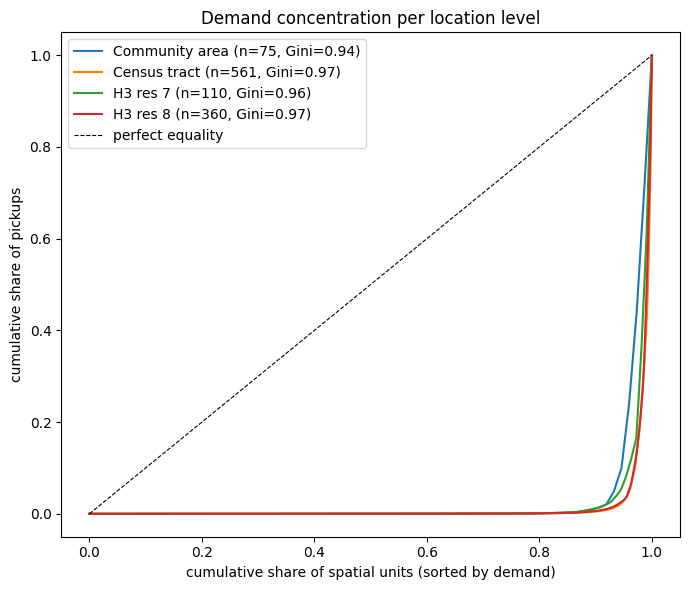

In [11]:
#| label: fig-loc-lorenz
#| fig-cap: "Lorenz curves of pickup demand across spatial units, per location level."
fig, ax = plt.subplots(figsize=(7, 6))
for name, c in unit_counts.items():
    v = np.sort(c.to_numpy(dtype=float))
    ax.plot(np.linspace(0, 1, len(v)), np.cumsum(v) / v.sum(),
            label=f"{name} (n={len(v)}, Gini={gini(v):.2f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="perfect equality")
ax.set_xlabel("cumulative share of spatial units (sorted by demand)")
ax.set_ylabel("cumulative share of pickups")
ax.set_title("Demand concentration per location level")
ax.legend()
plt.tight_layout()
plt.show()

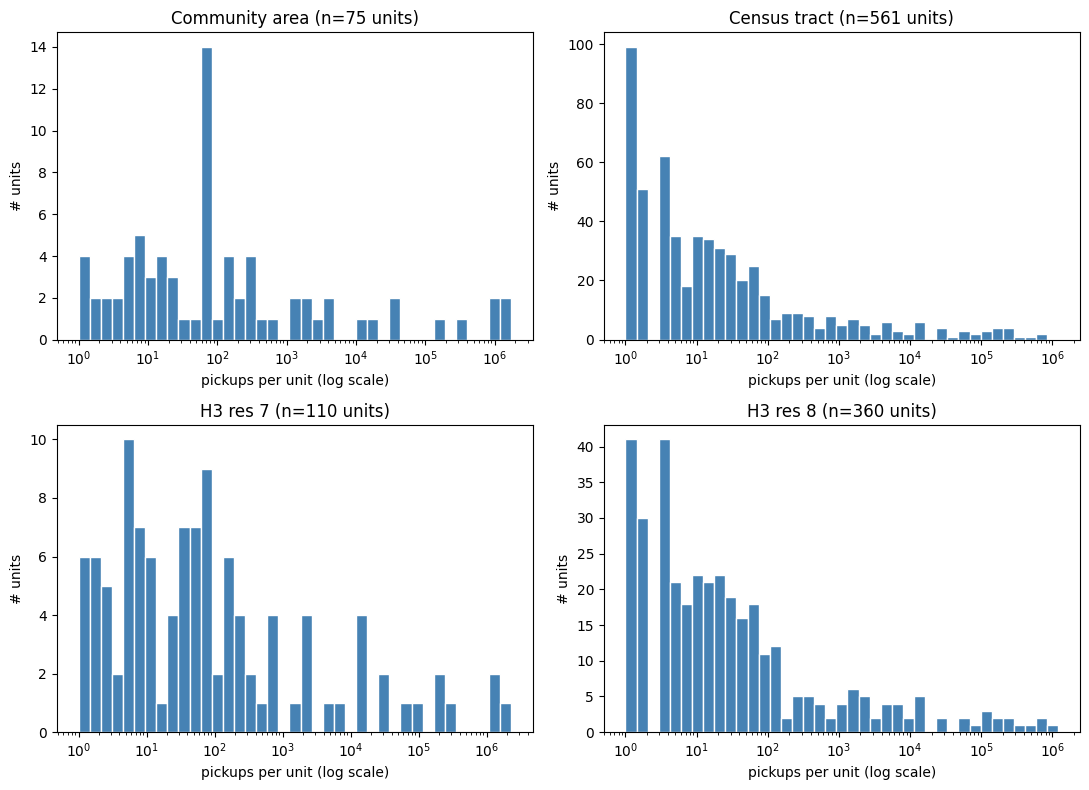

In [12]:
#| label: fig-loc-hist
#| fig-cap: "Histogram of pickups per spatial unit (log-scaled x-axis), per location level."
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=False)
for ax, (name, c) in zip(axes.ravel(), unit_counts.items()):
    v = c.to_numpy(dtype=float)
    bins = np.logspace(0, np.log10(v.max()), 40)
    ax.hist(v, bins=bins, color="steelblue", edgecolor="white")
    ax.set_xscale("log")
    ax.set_title(f"{name} (n={len(v)} units)")
    ax.set_xlabel("pickups per unit (log scale)")
    ax.set_ylabel("# units")
plt.tight_layout()
plt.show()

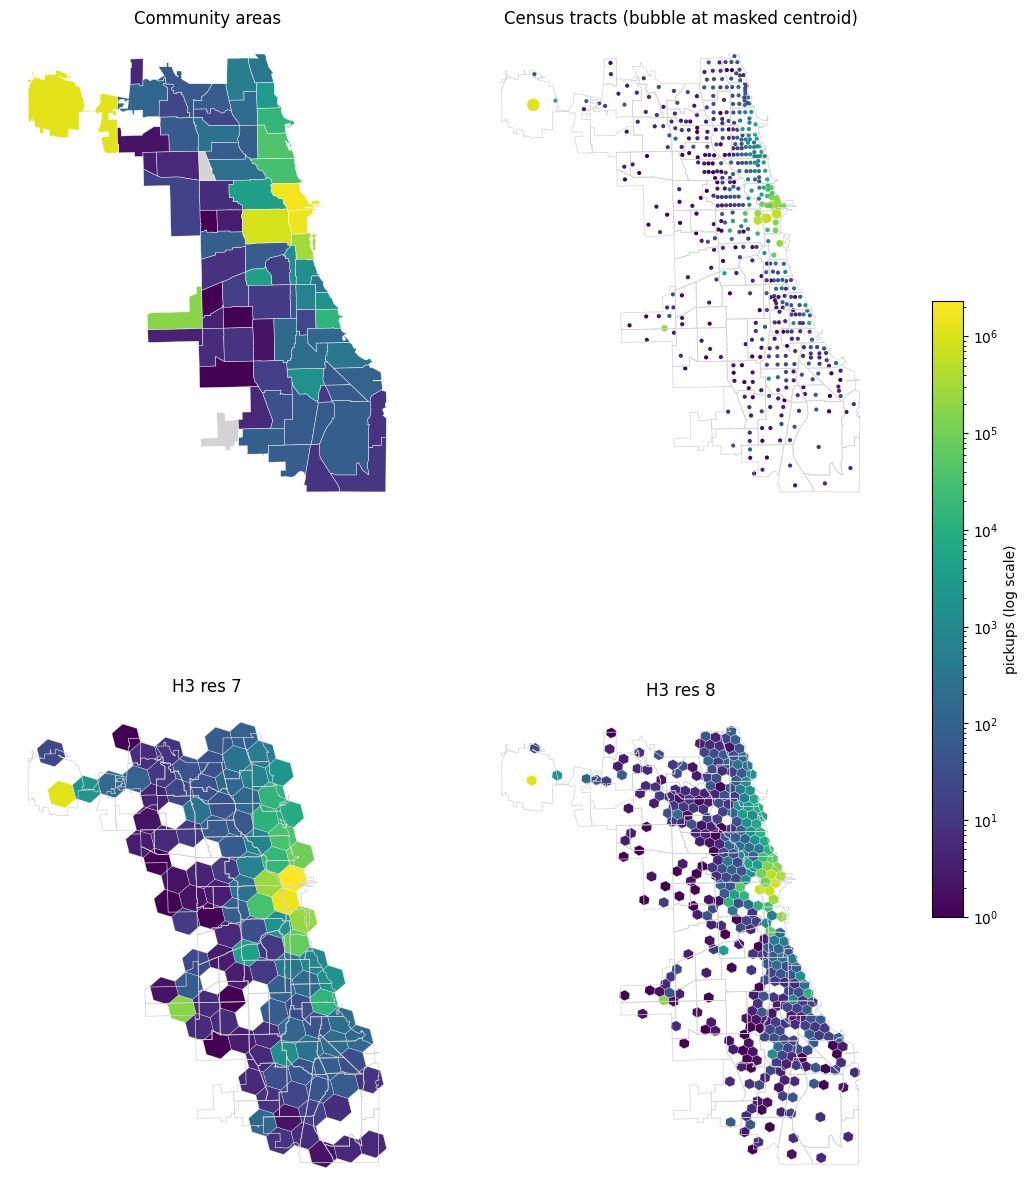

In [13]:
#| label: fig-loc-maps
#| fig-cap: "Spatial distribution of pickups at each location level (log colour scale)."
def h3_gdf(counts):
    return gpd.GeoDataFrame(
        {"pickups": counts.values},
        geometry=[Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)])
                  for cell in counts.index],
        crs="EPSG:4326",
    )

fig, axes = plt.subplots(2, 2, figsize=(14, 16))
norm = mcolors.LogNorm(vmin=1, vmax=max(c.max() for c in unit_counts.values()))

# Community areas (polygons from the gpkg)
ca_counts = unit_counts["Community area"]
cas_plot = cas.assign(ca_num=cas["area_numbe"].astype(int)).merge(
    ca_counts.rename("pickups"), left_on="ca_num", right_index=True, how="left")
cas_plot.plot(column="pickups", ax=axes[0, 0], cmap="viridis", norm=norm,
              edgecolor="white", linewidth=0.3, missing_kwds={"color": "lightgray"})
axes[0, 0].set_title("Community areas")

# Census tracts (no polygons in repo -> bubble map at tract centroids)
tract_pts = (coords.dropna(subset=["tract"]).drop_duplicates("tract").set_index("tract"))
tract_counts = unit_counts["Census tract"]
pts = tract_pts.join(tract_counts.rename("pickups"), how="inner")
cas.boundary.plot(ax=axes[0, 1], color="lightgray", linewidth=0.5)
axes[0, 1].scatter(pts["lng"], pts["lat"], s=4 + 60 * pts["pickups"] / pts["pickups"].max(),
                   c=pts["pickups"], cmap="viridis", norm=norm)
axes[0, 1].set_title("Census tracts (bubble at masked centroid)")

for ax, level in [(axes[1, 0], "H3 res 7"), (axes[1, 1], "H3 res 8")]:
    g = h3_gdf(unit_counts[level])
    cas.boundary.plot(ax=ax, color="lightgray", linewidth=0.5)
    g.plot(column="pickups", ax=ax, cmap="viridis", norm=norm, edgecolor="white", linewidth=0.2)
    ax.set_title(level)

for ax in axes.ravel():
    ax.set_axis_off()
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=axes,
             shrink=0.5, label="pickups (log scale)")
plt.show()

## 6. Temporal sparsity: unit-hour coverage

For demand prediction the data is aggregated to unit × hour cells. The share of *empty* cells at
each level quantifies the sparsity cost of finer spatial resolution.

In [14]:
#| label: tbl-loc-coverage
#| tbl-cap: "Coverage of the unit-hour grid per location level (pickups)."
n_hours = int((raw["start_hour"].max() - raw["start_hour"].min()) / pd.Timedelta("1h")) + 1
print(f"Time span: {raw['start_hour'].min()} to {raw['start_hour'].max()} ({n_hours:,} hourly bins)")

coverage_rows = []
for name, col in levels_units.items():
    sub = raw[[col, "start_hour"]].dropna(subset=[col])
    active_hours = sub.groupby(col, observed=True)["start_hour"].nunique()
    active_hours = active_hours[active_hours > 0]
    n_units = len(active_hours)
    nonzero_cells = int(active_hours.sum())
    total_cells = n_units * n_hours
    coverage_rows.append({
        "level": name,
        "# units": n_units,
        "unit-hour cells": total_cells,
        "non-empty cells": nonzero_cells,
        "% empty cells": round(100 * (1 - nonzero_cells / total_cells), 1),
        "median active hours/unit": float(active_hours.median()),
        "mean pickups per non-empty cell": round(len(sub) / nonzero_cells, 2),
    })
coverage = pd.DataFrame(coverage_rows).set_index("level")
coverage

Time span: 2024-01-01 00:00:00 to 2026-04-30 23:00:00 (20,424 hourly bins)


,# units,unit-hour cells,non-empty cells,% empty cells,median active hours/unit,mean pickups per non-empty cell
level,,,,,,
Community area,75,1531800,132512,91.3,51.0,45.57
Census tract,561,11457864,390404,96.6,7.0,15.47
H3 res 7,110,2246640,159786,92.9,34.0,37.81
H3 res 8,360,7352640,297013,96.0,10.0,20.34


## 7. Summary: comparing the location levels

In [15]:
#| label: tbl-loc-comparison
#| tbl-cap: "Overall comparison of all location levels in the raw taxi data."
precision_note = {
    "Community area": "true CA-level information",
    "Census tract": "true tract-level information where disclosed",
    "H3 res 7": "derived; bounded by tract/CA centroid masking",
    "H3 res 8": "derived; bounded by tract/CA centroid masking",
}
missing_pct = {
    "Community area": missingness.loc["Community area", "% missing (pickup)"],
    "Census tract": missingness.loc["Census tract", "% missing (pickup)"],
    "H3 res 7": missingness.loc["H3 res 7 (derived)", "% missing (pickup)"],
    "H3 res 8": missingness.loc["H3 res 8 (derived)", "% missing (pickup)"],
}
comparison = pd.DataFrame({
    "# units": sparsity["# units"],
    "% pickup endpoints missing": pd.Series(missing_pct),
    "median trips/unit": sparsity["median trips/unit"],
    "Gini (demand concentration)": sparsity["Gini"],
    "% empty unit-hours": coverage["% empty cells"],
    "effective precision": pd.Series(precision_note),
}).loc[list(levels_units.keys())]
comparison

,# units,% pickup endpoints missing,median trips/unit,Gini (demand concentration),% empty unit-hours,effective precision
Community area,75,0.04,70.0,0.944,91.3,true CA-level information
Census tract,561,0.00,10.0,0.974,96.6,true tract-level information where disclosed
H3 res 7,110,0.00,46.0,0.963,92.9,derived; bounded by tract/CA centroid masking
H3 res 8,360,0.00,14.0,0.972,96.0,derived; bounded by tract/CA centroid masking


### Verdict

- **Coordinates are not point data.** All ~12.1 M trip endpoints snap to just **634 unique
  positions** — exactly one per census tract (the tract↔coordinate mapping is strictly 1:1, zero
  violations). Treating them as GPS points vastly overstates spatial precision.
- **Census tract is the anchor level of this extract**: 100 % complete for both pickup and
  dropoff, which confirms the pre-filtering described in `1.1 TaxiDataPrep.ipynb`. The portal's
  privacy suppression of tracts is no longer visible in this file — there are **zero**
  community-area-masked centroids left.
- **Community area is *less* complete than census tract here** (0.04 % pickup / 1.44 % dropoff
  endpoints missing): trips crossing the city boundary carry an (out-of-city) tract but no CA,
  and those endpoints mostly lack coordinates entirely (232 pickups / 14,311 dropoffs). Without
  coordinates they get no H3 cell either, so `1.1`'s row-dropping silently removes exactly these
  boundary-crossing trips.
- **H3 inherits, rather than adds, precision.** H3 availability equals coordinate availability by
  construction. Res 7 collapses up to 21 tract centroids (mean 5.2) into a single cell — coarser
  than the tract level; res 8 keeps them mostly separate (mean 1.4 per cell) and behaves almost
  identically to the tract level in sparsity (96.0 % vs 96.6 % empty unit-hours, median 14 vs 10
  trips/unit), while res 7 behaves like the CA level (92.9 % vs 91.3 % empty). A resolution finer
  than 8 cannot recover information the centroid masking already removed.
- **Demand is extremely concentrated at every level** (Gini 0.94–0.97; the top-10 % of units carry
  ~99 % of pickups). Sparsity is therefore driven less by the choice of spatial resolution than by
  demand piling up in a handful of downtown/airport units — most units are near-empty at *any*
  level.
